# Import Libraries

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# LogisticRegressionMiniBatch class Implementation

In [2]:
class LogisticRegressionMiniBatch:
    def __init__(self, learning_rate=0.01, iterations=100, batch_size=32):
        self.lr = learning_rate
        self.iterations = iterations
        self.batch_size = batch_size
        self.weights = None
        self.bias = 0
        self.cost_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def cost(self, y_pred, y_true):
        return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)

        # Mini-batch Gradient Descent
        for epoch in range(self.iterations):
            epoch_cost = 0
            indices = np.random.permutation(n_samples)

            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                batch_idx = indices[start:end]
                X_batch = X[batch_idx]
                y_batch = y[batch_idx]
                batch_len = len(batch_idx)

                # Forward pass on mini-batch
                linear_model = np.dot(X_batch, self.weights) + self.bias
                y_pred = self.sigmoid(linear_model)

                # Compute gradients on mini-batch
                dw = (1 / batch_len) * np.dot(X_batch.T, (y_pred - y_batch))
                db = (1 / batch_len) * np.sum(y_pred - y_batch)

                # Update parameters
                self.weights -= self.lr * dw
                self.bias -= self.lr * db

                epoch_cost += self.cost(y_pred, y_batch)

            num_batches = int(np.ceil(n_samples / self.batch_size))
            self.cost_history.append(epoch_cost / num_batches)

    def predict(self, X):
        return (self.sigmoid(np.dot(X, self.weights) + self.bias) >= 0.5).astype(int)

# Prepare Data

In [3]:
np.random.seed(42)
X = np.random.randn(500, 2) * 10
y = (np.dot(X, np.array([3, -2])) + 1 > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Models with Different Batch Sizes

In [4]:
batch_sizes = [1, 32, 128, len(X_train)]
models = {}

for bs in batch_sizes:
    label = f"batch_size={bs}"
    model = LogisticRegressionMiniBatch(learning_rate=0.01, iterations=100, batch_size=bs)
    model.fit(X_train, y_train)
    models[label] = model

# Evaluate the Models

In [5]:
for label, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = np.mean(y_pred == y_test)
    print(f"{label}: Accuracy = {accuracy:.2f}")

batch_size=1: Accuracy = 0.98
batch_size=32: Accuracy = 0.97
batch_size=128: Accuracy = 0.97
batch_size=400: Accuracy = 0.97


# Visualize Cost Function Convergence

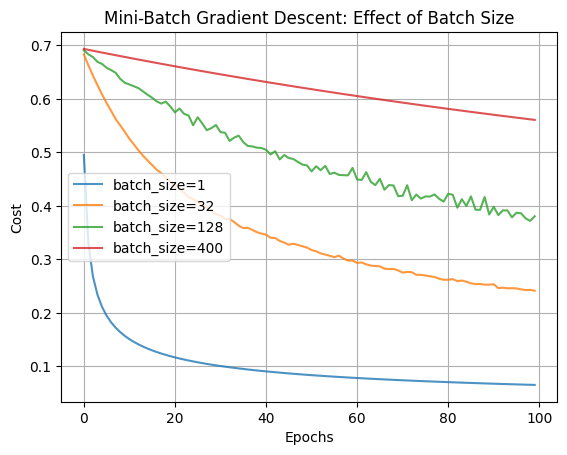

In [6]:
for label, model in models.items():
    plt.plot(model.cost_history, label=label, alpha=0.8)

plt.title('Mini-Batch Gradient Descent: Effect of Batch Size')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()